<a href="https://colab.research.google.com/github/shonnvs-code/Team4-A1-BA820-Project/blob/main/M2_FILES/Copy_of_Shon_Shaju_ProjectM2_Q2_BA820_Team_4_Childcare_Costs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Childcare Costs Dataset**


# **1. Executive Summary**

Childcare isn't just a family issue; it’s a major economic factor. In the U.S., childcare is often one of the biggest expenses for a household, sometimes costing between 8.9% and 16% of a family's income, in many places, that is more than rent!

Research shows that when prices go up, parents (especially mothers) are often forced to leave the workforce. This project looks beyond just "average prices" to understand the diverse childcare markets across the U.S. We want to understand how costs relate to income, employment, and local economies so policymakers and employers can make better decisions.

# **2.Question under analysis**

Q2.How do U.S. counties cluster into distinct childcare market types based on pricing structure and affordability pressure, and how do these market types differ in maternal labor force participation? Specifically, do clusters exist where maternal labor participation remains high despite extreme childcare cost-to-income ratios, or where participation remains low even at moderate cost levels?

# **3.Loading Data**

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
childcare = pd.read_csv('/content/drive/MyDrive/childcare_costs.csv')
counties  = pd.read_csv('/content/drive/MyDrive/counties.csv')

print("childcare shape:", childcare.shape)
print("counties shape:", counties.shape)
childcare.head()

childcare shape: (34567, 61)
counties shape: (3144, 4)


,county_fips_code,study_year,unr_16,funr_16,munr_16,unr_20to64,funr_20to64,munr_20to64,flfpr_20to64,flfpr_20to64_under6,...,memp_p,femp_p,mcsa,mfccsa,mc_infant,mc_toddler,mc_preschool,mfcc_infant,mfcc_toddler,mfcc_preschool
0,1001,2008,5.42,4.41,6.32,4.6,3.5,5.6,68.9,66.9,...,21.55,4.07,80.92,81.40,104.95,104.95,85.92,83.45,83.45,81.40
1,1001,2009,5.93,5.72,6.11,4.8,4.6,5.0,70.8,63.7,...,21.96,5.19,83.42,85.68,105.11,105.11,87.59,87.39,87.39,85.68
2,1001,2010,6.21,5.57,6.78,5.1,4.6,5.6,71.3,67.0,...,21.28,4.13,85.92,89.96,105.28,105.28,89.26,91.33,91.33,89.96
3,1001,2011,7.55,8.13,7.03,6.2,6.3,6.1,70.2,66.5,...,22.80,4.77,88.43,94.25,105.45,105.45,90.93,95.28,95.28,94.25
4,1001,2012,8.60,8.88,8.29,6.7,6.4,7.0,70.6,67.1,...,22.88,4.84,90.93,98.53,105.61,105.61,92.60,99.22,99.22,98.53


In [6]:
# mereging both the data sets
df = childcare.merge(counties, on="county_fips_code", how="left")
df

,county_fips_code,study_year,unr_16,funr_16,munr_16,unr_20to64,funr_20to64,munr_20to64,flfpr_20to64,flfpr_20to64_under6,...,mfccsa,mc_infant,mc_toddler,mc_preschool,mfcc_infant,mfcc_toddler,mfcc_preschool,county_name,state_name,state_abbreviation
0,1001,2008,5.42,4.41,6.32,4.6,3.5,5.6,68.9,66.9,...,81.40,104.95,104.95,85.92,83.45,83.45,81.40,Autauga County,Alabama,AL
1,1001,2009,5.93,5.72,6.11,4.8,4.6,5.0,70.8,63.7,...,85.68,105.11,105.11,87.59,87.39,87.39,85.68,Autauga County,Alabama,AL
2,1001,2010,6.21,5.57,6.78,5.1,4.6,5.6,71.3,67.0,...,89.96,105.28,105.28,89.26,91.33,91.33,89.96,Autauga County,Alabama,AL
3,1001,2011,7.55,8.13,7.03,6.2,6.3,6.1,70.2,66.5,...,94.25,105.45,105.45,90.93,95.28,95.28,94.25,Autauga County,Alabama,AL
4,1001,2012,8.60,8.88,8.29,6.7,6.4,7.0,70.6,67.1,...,98.53,105.61,105.61,92.60,99.22,99.22,98.53,Autauga County,Alabama,AL
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34562,56045,2014,3.60,5.36,2.28,2.4,4.8,0.6,75.9,74.8,...,112.94,147.36,120.38,123.99,110.71,110.71,111.47,Weston County,Wyoming,WY
34563,56045,2015,5.16,7.86,3.16,4.2,7.6,1.6,73.2,82.0,...,110.89,140.36,118.77,118.77,110.89,110.89,110.89,Weston County,Wyoming,WY
34564,56045,2016,3.61,4.67,2.79,3.4,4.5,2.6,69.7,68.1,...,108.85,133.37,117.16,113.55,114.10,111.07,110.31,Weston County,Wyoming,WY
34565,56045,2017,2.24,2.64,1.95,2.3,2.8,2.0,71.4,63.6,...,106.81,126.38,115.55,108.32,117.30,111.26,109.74,Weston County,Wyoming,WY


# **4.EDA**

In [7]:
# Column names (fixed from your dataset)
income_col = "mhi_2018"
maternal_lfp_col = "flfpr_20to64_under6"

center_cols = ["mc_infant", "mc_toddler", "mc_preschool"]
family_cols = ["mfcc_infant", "mfcc_toddler", "mfcc_preschool"]

# Ensure numeric
for c in [income_col, maternal_lfp_col] + center_cols + family_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# Average childcare prices
df["center_avg"] = df[center_cols].mean(axis=1)
df["family_avg"] = df[family_cols].mean(axis=1)
df["overall_price_avg"] = df[["center_avg", "family_avg"]].mean(axis=1)

# Structural pricing features
df["infant_preschool_ratio_center"] = df["mc_infant"] / df["mc_preschool"]
df["infant_preschool_ratio_family"] = df["mfcc_infant"] / df["mfcc_preschool"]

df["center_minus_family"] = df["center_avg"] - df["family_avg"]
df["center_over_family"]  = df["center_avg"] / df["family_avg"]

# Affordability pressure (key variable for Q2)
df["afford_ratio"] = df["overall_price_avg"] / df[income_col]

df[["afford_ratio", maternal_lfp_col, "center_avg", "family_avg"]].describe()


,afford_ratio,flfpr_20to64_under6,center_avg,family_avg
count,23634.000000,34567.000000,23593.000000,23383.000000
mean,0.002430,68.821409,132.922463,108.123639
std,0.000593,11.758088,44.820901,30.331676
min,0.000535,0.000000,23.603333,43.080000
25%,0.002016,62.600000,101.900000,86.460000
50%,0.002376,69.600000,123.300000,102.316667
75%,0.002759,76.100000,150.000000,124.933333
max,0.006804,100.000000,413.333333,379.533333


clustermaking

In [8]:
cluster_features = [
    "afford_ratio",
    "infant_preschool_ratio_center",
    "infant_preschool_ratio_family",
    "center_minus_family",
    "center_over_family"
]

X_raw = df[cluster_features].copy()

prep = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

X = prep.fit_transform(X_raw)
print("X shape:", X.shape)


X shape: (34567, 5)


k means

silhouette Method

In [9]:
results = []
for k in [3, 4, 5, 6]:
    km = KMeans(n_clusters=k, n_init=20, random_state=42)
    labels = km.fit_predict(X)
    sil = silhouette_score(X, labels)
    results.append((k, sil))

results_df = pd.DataFrame(results, columns=["k", "silhouette"]).sort_values("silhouette", ascending=False)
results_df


,k,silhouette
0,3,0.457675
3,6,0.331946
2,5,0.319666
1,4,0.305532


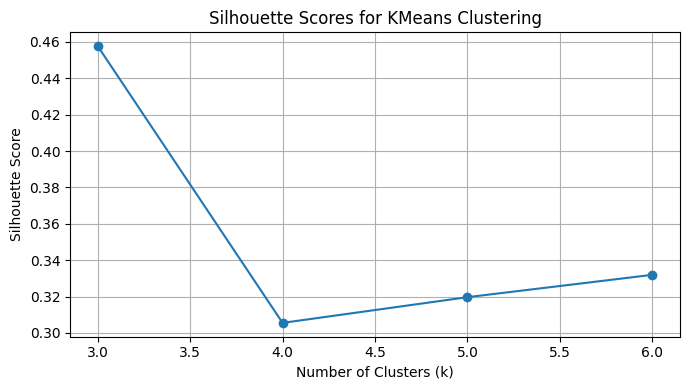

In [10]:
results_df_sorted = results_df.sort_values("k")

plt.figure(figsize=(7,4))
plt.plot(results_df_sorted["k"], results_df_sorted["silhouette"], marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Scores for KMeans Clustering")
plt.grid(True)
plt.tight_layout()
plt.show()


In [10]:
best_k = int(results_df.iloc[0]["k"])
print("Chosen k =", best_k)

km = KMeans(n_clusters=best_k, n_init=30, random_state=42)
df["cluster"] = km.fit_predict(X)

df["cluster"].value_counts().sort_index()


Chosen k = 3


,count
cluster,
0,438
1,453
2,2251


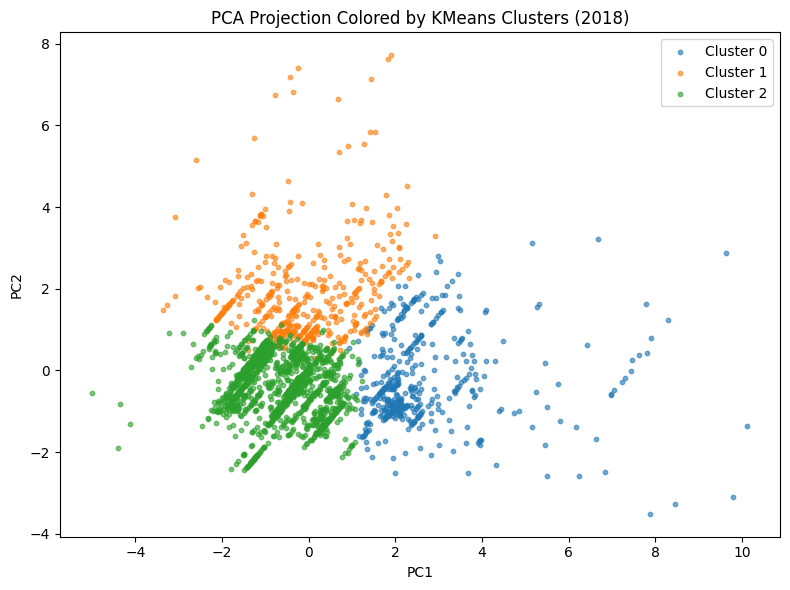

PCA explained variance (2 comps): 0.6433159995479453


In [11]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(8,6))
for c in sorted(df["cluster"].unique()):
    mask = df["cluster"] == c
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], s=10, alpha=0.6, label=f"Cluster {c}")

plt.title("PCA Projection Colored by KMeans Clusters (2018)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.tight_layout()
plt.show()

print("PCA explained variance (2 comps):", pca.explained_variance_ratio_.sum())


In [12]:
summary = (df.groupby("cluster")
           .agg(
               n=("afford_ratio","size"),
               afford_median=("afford_ratio","median"),
               afford_mean=("afford_ratio","mean"),
               lfp_median=(maternal_lfp_col,"median"),
               lfp_mean=(maternal_lfp_col,"mean"),
           )
           .sort_values("afford_median", ascending=False))

summary


,n,afford_median,afford_mean,lfp_median,lfp_mean
cluster,,,,,
1,453,0.003015,0.003064,70.20,68.383223
0,438,0.002893,0.002944,74.55,73.428767
2,2251,0.002394,0.002372,71.10,70.043523


In [13]:
income_col = "mhi_2018"
maternal_lfp_col = "flfpr_20to64_under6"

center_cols = ["mc_infant", "mc_toddler", "mc_preschool"]
family_cols = ["mfcc_infant", "mfcc_toddler", "mfcc_preschool"]

use_cols = [income_col, maternal_lfp_col] + center_cols + family_cols

for c in use_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df[use_cols].describe()


,mhi_2018,flfpr_20to64_under6,mc_infant,mc_toddler,mc_preschool,mfcc_infant,mfcc_toddler,mfcc_preschool
count,3142.000000,3142.000000,2360.000000,2360.000000,2360.000000,2348.000000,2348.000000,2348.000000
mean,51577.714405,70.276057,162.392076,145.958242,135.920983,125.615094,118.510217,115.353062
std,13704.739696,13.587340,58.159559,47.515914,42.977066,36.373461,33.218373,32.605517
min,20188.000000,0.000000,27.730000,21.540000,21.540000,47.660000,46.970000,40.030000
25%,42478.500000,63.500000,126.397500,116.192500,105.950000,100.000000,96.250000,93.772500
50%,49887.500000,71.700000,153.600000,140.000000,125.000000,120.000000,113.040000,110.000000
75%,57605.000000,78.500000,182.292500,165.000000,153.400000,145.000000,135.000000,131.540000
max,136268.000000,100.000000,470.000000,419.000000,385.000000,430.940000,376.320000,331.340000


In [14]:
# Averages
df["center_avg"] = df[center_cols].mean(axis=1)
df["family_avg"] = df[family_cols].mean(axis=1)
df["overall_price_avg"] = df[["center_avg", "family_avg"]].mean(axis=1)

# Structure measures
df["infant_preschool_ratio_center"] = df["mc_infant"] / df["mc_preschool"]
df["infant_preschool_ratio_family"] = df["mfcc_infant"] / df["mfcc_preschool"]
df["center_minus_family"] = df["center_avg"] - df["family_avg"]
df["center_over_family"]  = df["center_avg"] / df["family_avg"]

# Affordability pressure (core Q2 variable)
df["afford_ratio"] = df["overall_price_avg"] / df[income_col]

df[["afford_ratio", maternal_lfp_col, "center_avg", "family_avg"]].describe()


,afford_ratio,flfpr_20to64_under6,center_avg,family_avg
count,2368.000000,3142.000000,2360.000000,2348.000000
mean,0.002610,70.276057,148.090434,119.826124
std,0.000587,13.587340,48.896063,33.774552
min,0.000535,0.000000,23.603333,45.366667
25%,0.002231,63.500000,115.673333,97.500000
50%,0.002581,71.700000,142.100000,115.000000
75%,0.002954,78.500000,164.696667,136.666667
max,0.006804,100.000000,413.333333,379.533333


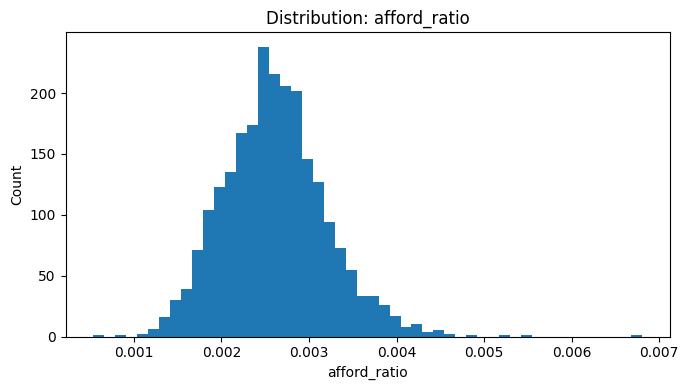

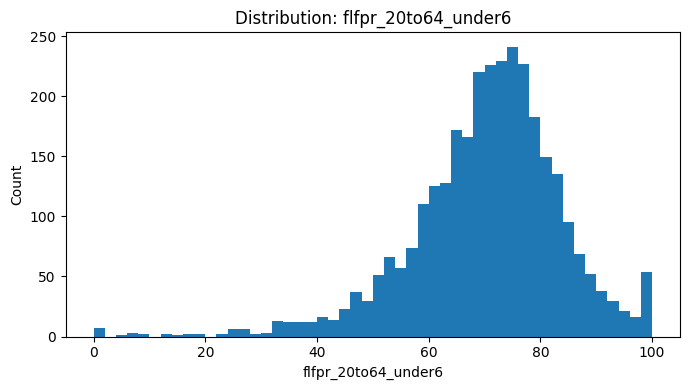

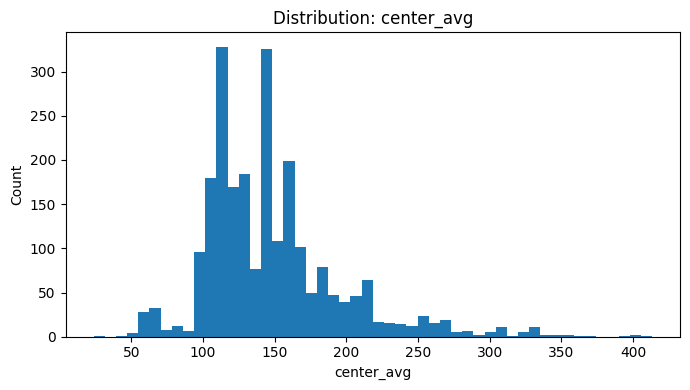

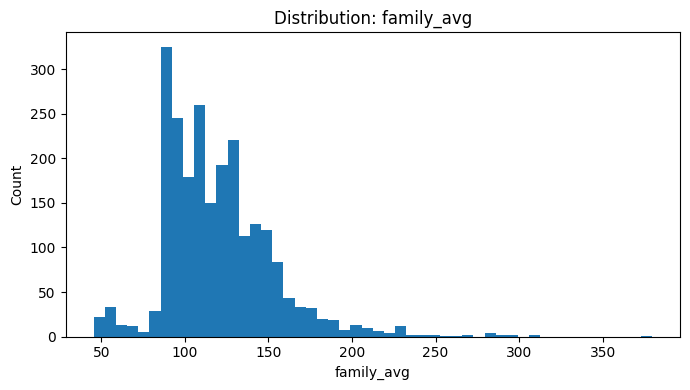

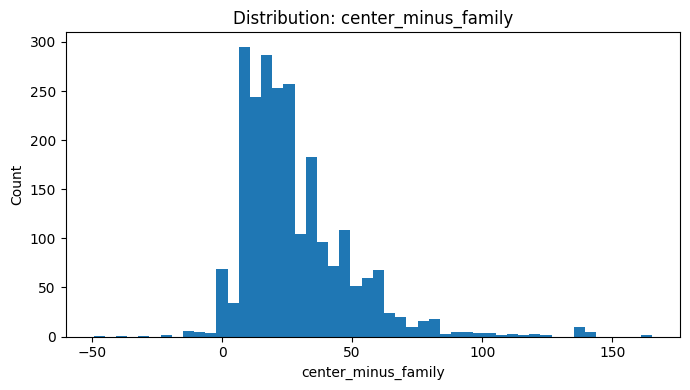

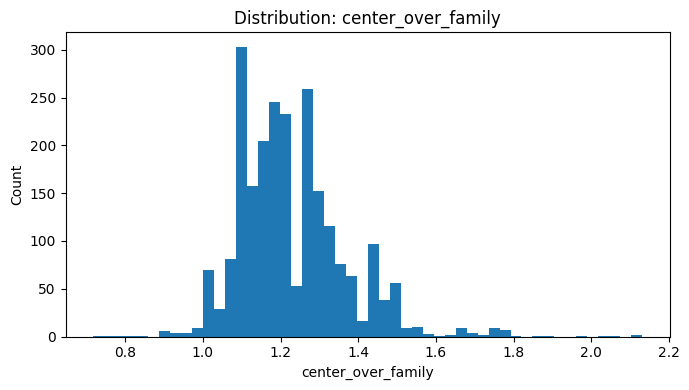

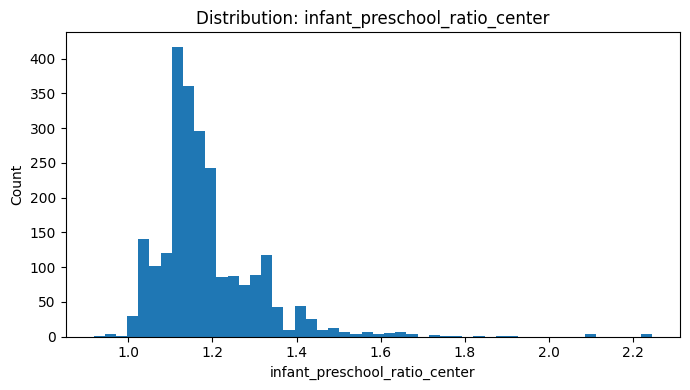

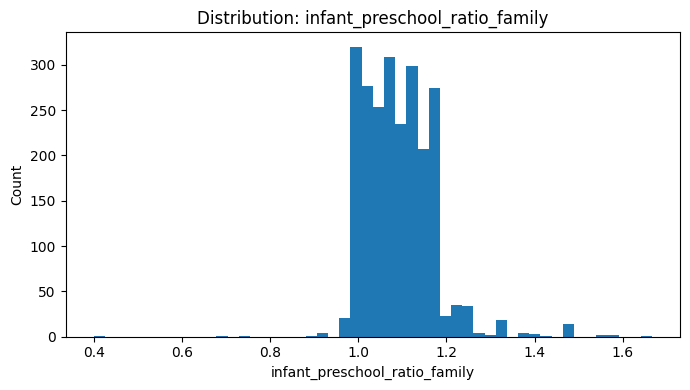

In [15]:
eda_cols = ["afford_ratio", maternal_lfp_col, "center_avg", "family_avg",
            "center_minus_family", "center_over_family",
            "infant_preschool_ratio_center", "infant_preschool_ratio_family"]

eda_cols = [c for c in eda_cols if c in df.columns]

for col in eda_cols:
    plt.figure(figsize=(7,4))
    x = df[col].dropna()
    plt.hist(x, bins=50)
    plt.title(f"Distribution: {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()


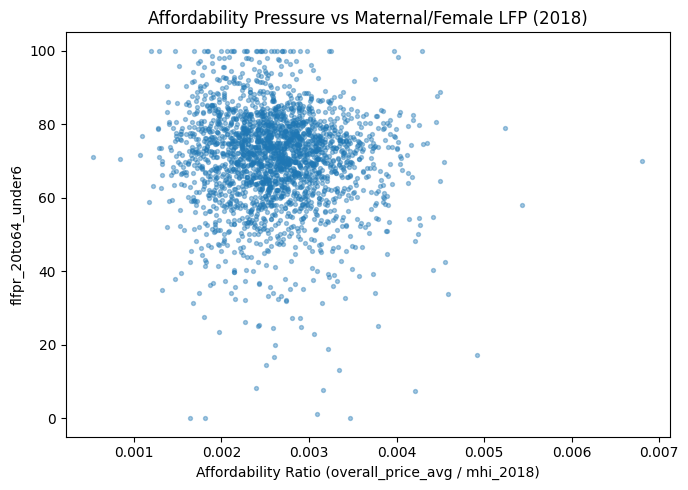

Correlation (afford_ratio, maternal LFP): -0.0796


In [16]:
plt.figure(figsize=(7,5))
sub = df[[ "afford_ratio", maternal_lfp_col ]].dropna()
plt.scatter(sub["afford_ratio"], sub[maternal_lfp_col], s=8, alpha=0.4)
plt.title("Affordability Pressure vs Maternal/Female LFP (2018)")
plt.xlabel("Affordability Ratio (overall_price_avg / mhi_2018)")
plt.ylabel("flfpr_20to64_under6")
plt.tight_layout()
plt.show()

# Correlation (simple)
corr = sub["afford_ratio"].corr(sub[maternal_lfp_col])
print("Correlation (afford_ratio, maternal LFP):", round(corr, 4))


In [17]:
q95 = df["afford_ratio"].quantile(0.95)
hi = df[df["afford_ratio"] >= q95].copy()

print("Top 5% affordability pressure threshold:", q95)
print("Rows in top 5%:", len(hi))

show_cols = ["county_name","state_abbreviation","afford_ratio", maternal_lfp_col, "center_avg","family_avg", income_col]
show_cols = [c for c in show_cols if c in df.columns]

display(hi.sort_values("afford_ratio", ascending=False)[show_cols].head(20))


Top 5% affordability pressure threshold: 0.003617626830524398
Rows in top 5%: 119


,county_name,state_abbreviation,afford_ratio,flfpr_20to64_under6,center_avg,family_avg,mhi_2018
20139,Bronx County,NY,0.006804,70.0,329.783333,188.440000,38085.0
25507,Allendale County,SC,0.005429,58.0,151.666667,115.000000,24560.0
33972,Milwaukee County,WI,0.005238,79.0,290.666667,220.000000,48742.0
28015,Brooks County,TX,0.004921,17.2,142.100000,127.333333,27378.0
11735,McCreary County,KY,0.004589,33.9,120.286667,93.333333,23273.0
12230,Wolfe County,KY,0.004555,42.4,106.666667,97.916667,22458.0
20370,Kings County,NY,0.004538,69.7,324.080000,184.266667,56015.0
34533,Teton County,WY,0.004496,88.8,374.293333,379.533333,83831.0
2176,Humboldt County,CA,0.004492,64.5,230.976667,178.033333,45528.0
351,Greene County,AL,0.004466,87.8,107.140000,87.610000,21804.0


,n,afford_median,lfp_median,income_median,center_median,family_median
state_abbreviation,,,,,,
AK,29,0.003521,70.40,69706.0,278.270000,162.693333
MA,14,0.003515,78.30,70922.5,271.666667,227.083333
WA,39,0.003338,63.60,54852.0,215.923333,170.003333
VT,14,0.003327,78.30,59231.0,220.645000,158.533333
NY,62,0.003241,75.00,55890.0,206.786667,152.868333
CA,58,0.003230,66.40,59157.5,215.991667,173.728333
CT,8,0.003071,77.95,75317.5,284.166667,196.000000
ME,16,0.003042,73.90,51488.0,177.916667,138.333333
OR,36,0.003035,67.60,49287.5,156.540000,127.060000


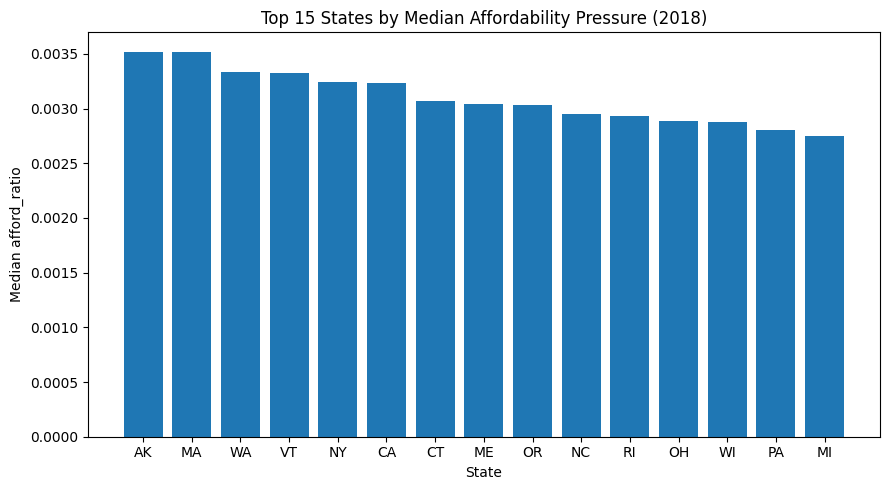

In [18]:
state_summary = (df.groupby("state_abbreviation")
                 .agg(
                     n=("afford_ratio","size"),
                     afford_median=("afford_ratio","median"),
                     lfp_median=(maternal_lfp_col,"median"),
                     income_median=(income_col,"median"),
                     center_median=("center_avg","median"),
                     family_median=("family_avg","median"),
                 )
                 .sort_values("afford_median", ascending=False))

display(state_summary.head(15))

# Quick bar chart: top 15 states by affordability pressure
top15 = state_summary.head(15)
plt.figure(figsize=(9,5))
plt.bar(top15.index, top15["afford_median"])
plt.title("Top 15 States by Median Affordability Pressure (2018)")
plt.xlabel("State")
plt.ylabel("Median afford_ratio")
plt.tight_layout()
plt.show()


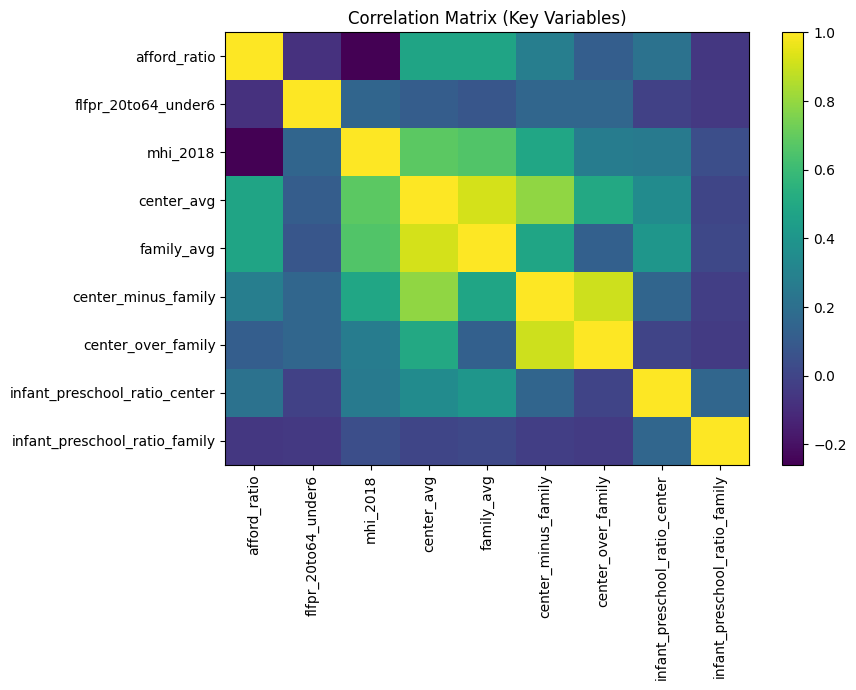

,afford_ratio,flfpr_20to64_under6,mhi_2018,center_avg,family_avg,center_minus_family,center_over_family,infant_preschool_ratio_center,infant_preschool_ratio_family
afford_ratio,1.000000,-0.079593,-0.258836,0.474013,0.477666,0.278440,0.119283,0.213469,-0.056695
flfpr_20to64_under6,-0.079593,1.000000,0.153881,0.114595,0.075901,0.158327,0.155887,-0.014659,-0.048270
mhi_2018,-0.258836,0.153881,1.000000,0.683167,0.657698,0.486194,0.270706,0.253109,0.042997
center_avg,0.474013,0.114595,0.683167,1.000000,0.917248,0.789138,0.498650,0.349245,0.002110
family_avg,0.477666,0.075901,0.657698,0.917248,1.000000,0.479184,0.125283,0.403695,0.016064
center_minus_family,0.278440,0.158327,0.486194,0.789138,0.479184,1.000000,0.905618,0.152468,-0.024507
center_over_family,0.119283,0.155887,0.270706,0.498650,0.125283,0.905618,1.000000,0.000725,-0.040892
infant_preschool_ratio_center,0.213469,-0.014659,0.253109,0.349245,0.403695,0.152468,0.000725,1.000000,0.157651
infant_preschool_ratio_family,-0.056695,-0.048270,0.042997,0.002110,0.016064,-0.024507,-0.040892,0.157651,1.000000


In [19]:
corr_cols = [
    "afford_ratio", maternal_lfp_col, income_col,
    "center_avg", "family_avg",
    "center_minus_family", "center_over_family",
    "infant_preschool_ratio_center", "infant_preschool_ratio_family"
]
corr_cols = [c for c in corr_cols if c in df.columns]

corr_df = df[corr_cols].copy()
corr_mat = corr_df.corr(numeric_only=True)

plt.figure(figsize=(9,7))
plt.imshow(corr_mat, aspect="auto")
plt.title("Correlation Matrix (Key Variables)")
plt.xticks(range(len(corr_cols)), corr_cols, rotation=90)
plt.yticks(range(len(corr_cols)), corr_cols)
plt.colorbar()
plt.tight_layout()
plt.show()

display(corr_mat)


In [20]:
aff_q75 = df["afford_ratio"].quantile(0.75)
aff_q25 = df["afford_ratio"].quantile(0.25)

lfp_q75 = df[maternal_lfp_col].quantile(0.75)
lfp_q25 = df[maternal_lfp_col].quantile(0.25)

high_cost_high_lfp = df[(df["afford_ratio"] >= aff_q75) & (df[maternal_lfp_col] >= lfp_q75)].copy()
moderate_cost_low_lfp = df[(df["afford_ratio"].between(aff_q25, aff_q75)) & (df[maternal_lfp_col] <= lfp_q25)].copy()

print("High cost + high LFP rows:", len(high_cost_high_lfp))
print("Moderate cost + low LFP rows:", len(moderate_cost_low_lfp))

show_cols = ["county_name","state_abbreviation","afford_ratio", maternal_lfp_col, income_col, "center_avg","family_avg"]
display(high_cost_high_lfp.sort_values("afford_ratio", ascending=False)[show_cols].head(15))
display(moderate_cost_low_lfp.sort_values(maternal_lfp_col, ascending=True)[show_cols].head(15))


High cost + high LFP rows: 114
Moderate cost + low LFP rows: 263


,county_name,state_abbreviation,afford_ratio,flfpr_20to64_under6,mhi_2018,center_avg,family_avg
33972,Milwaukee County,WI,0.005238,79.0,48742.0,290.666667,220.000000
34533,Teton County,WY,0.004496,88.8,83831.0,374.293333,379.533333
351,Greene County,AL,0.004466,87.8,21804.0,107.140000,87.610000
13528,Suffolk County,MA,0.004452,80.7,64582.0,350.000000,225.000000
32168,Emporia city,VA,0.004294,100.0,30857.0,143.333333,121.666667
31007,Windham County,VT,0.004254,79.7,52659.0,248.833333,199.166667
30919,Essex County,VT,0.004190,82.4,41045.0,207.876667,136.063333
23021,Mahoning County,OH,0.004184,81.1,44682.0,216.666667,157.223333
582,Perry County,AL,0.004133,79.6,23561.0,107.140000,87.610000
25848,Marion County,SC,0.004035,83.2,33046.0,151.666667,115.000000


,county_name,state_abbreviation,afford_ratio,flfpr_20to64_under6,mhi_2018,center_avg,family_avg
18830,Loup County,NE,0.002395,8.3,53125.0,143.800000,110.666667
23747,Greer County,OK,0.002511,14.6,38322.0,105.330000,87.153333
18841,McPherson County,NE,0.002603,16.7,48882.0,143.800000,110.666667
21019,Chowan County,NC,0.002609,19.9,42621.0,111.656667,110.770000
15761,Jefferson County,MS,0.002586,24.6,20188.0,55.663333,48.743333
505,Marengo County,AL,0.002908,24.9,32809.0,103.720000,87.110000
29390,Live Oak County,TX,0.002416,25.0,55766.0,142.100000,127.333333
30116,Stephens County,TX,0.002424,25.3,45336.0,116.733333,103.083333
28664,Gaines County,TX,0.002271,26.3,59032.0,141.966667,126.200000
2066,Alpine County,CA,0.002896,27.3,64688.0,210.240000,164.496667


In [21]:
# Check if ratios are exploding due to small denominators / missing values
bad_center_ratio = df["infant_preschool_ratio_center"].replace([np.inf, -np.inf], np.nan)
bad_family_ratio = df["infant_preschool_ratio_family"].replace([np.inf, -np.inf], np.nan)

print("Center ratio missing %:", bad_center_ratio.isna().mean())
print("Family ratio missing %:", bad_family_ratio.isna().mean())

# If the missingness is high, you can say:
# "Some gradient features had substantial missingness / instability, so we relied more on affordability + provider gap features."


Center ratio missing %: 0.24888605983450032
Family ratio missing %: 0.25270528325907066


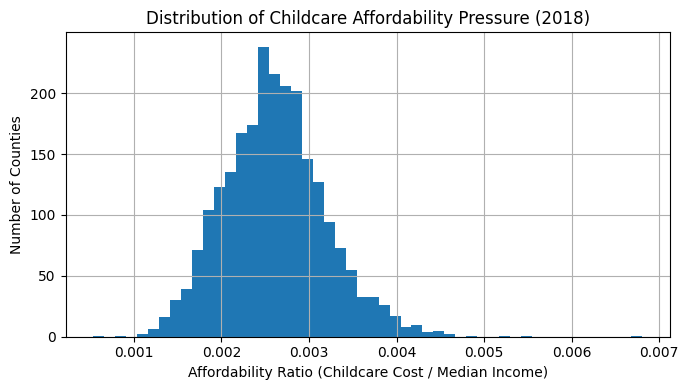

In [22]:
plt.figure(figsize=(7,4))
df["afford_ratio"].dropna().hist(bins=50)
plt.title("Distribution of Childcare Affordability Pressure (2018)")
plt.xlabel("Affordability Ratio (Childcare Cost / Median Income)")
plt.ylabel("Number of Counties")
plt.tight_layout()
plt.show()

The affordability ratio is strongly right-skewed, with most counties facing moderate childcare cost pressure and a long tail of counties experiencing extremely high costs relative to income. This indicates that affordability challenges are not evenly distributed and that average values obscure a subset of structurally stressed childcare markets

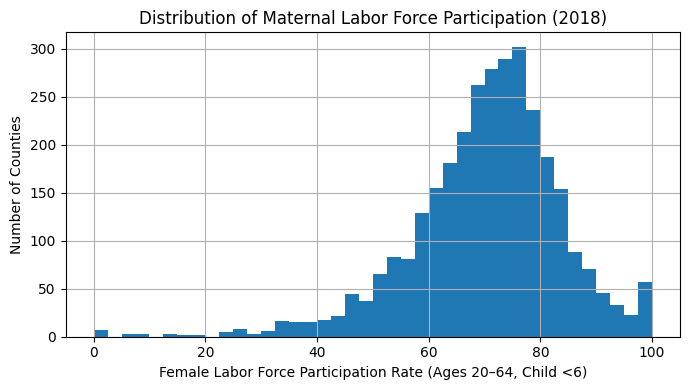

In [23]:
plt.figure(figsize=(7,4))
df["flfpr_20to64_under6"].dropna().hist(bins=40)
plt.title("Distribution of Maternal Labor Force Participation (2018)")
plt.xlabel("Female Labor Force Participation Rate (Ages 20–64, Child <6)")
plt.ylabel("Number of Counties")
plt.tight_layout()
plt.show()


Maternal labor force participation exhibits a narrower and more symmetric distribution than affordability pressure, suggesting that participation outcomes are more stable across counties. This implies that labor participation may be influenced by multiple compensating factors rather than responding directly to childcare costs alone.

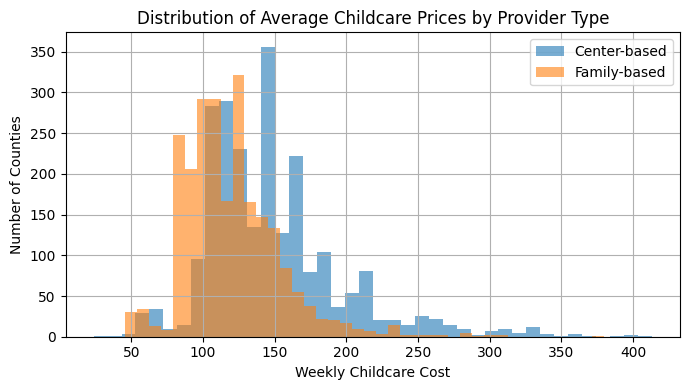

In [24]:
plt.figure(figsize=(7,4))
df["center_avg"].dropna().hist(bins=40, alpha=0.6, label="Center-based")
df["family_avg"].dropna().hist(bins=40, alpha=0.6, label="Family-based")
plt.title("Distribution of Average Childcare Prices by Provider Type")
plt.xlabel("Weekly Childcare Cost")
plt.ylabel("Number of Counties")
plt.legend()
plt.tight_layout()
plt.show()


Center-based childcare is generally more expensive than family-based care, but the overlap between the distributions indicates substantial variation across counties. This suggests that provider substitution opportunities differ by local market, reflecting heterogeneous supply conditions.

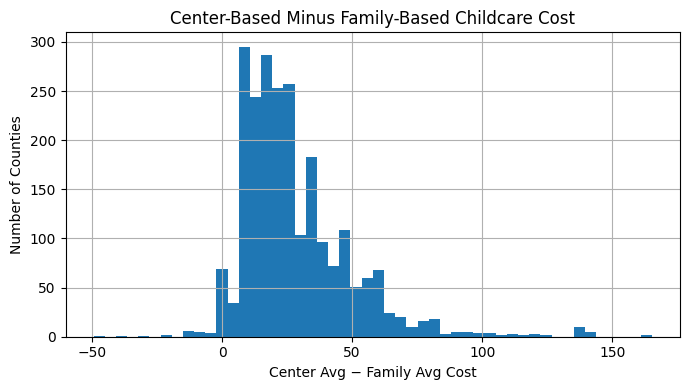

In [25]:
plt.figure(figsize=(7,4))
df["center_minus_family"].dropna().hist(bins=50)
plt.title("Center-Based Minus Family-Based Childcare Cost")
plt.xlabel("Center Avg − Family Avg Cost")
plt.ylabel("Number of Counties")
plt.tight_layout()
plt.show()


The center–family price gap varies widely across counties, with some markets exhibiting large differences and others showing minimal gaps. This heterogeneity indicates that provider structure plays a meaningful role in shaping childcare affordability beyond overall price levels.

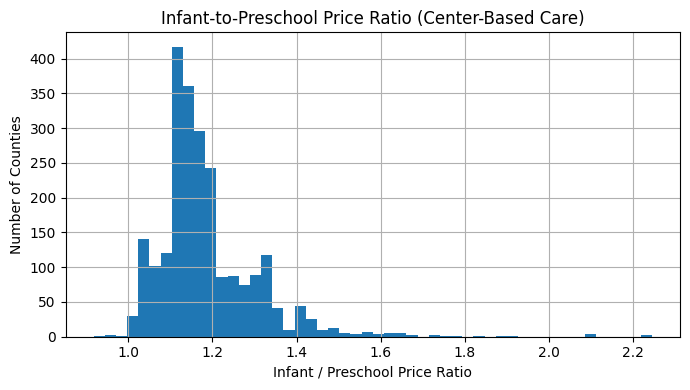

In [26]:
plt.figure(figsize=(7,4))
df["infant_preschool_ratio_center"].dropna().hist(bins=50)
plt.title("Infant-to-Preschool Price Ratio (Center-Based Care)")
plt.xlabel("Infant / Preschool Price Ratio")
plt.ylabel("Number of Counties")
plt.tight_layout()
plt.show()


Infant–preschool price ratios vary substantially across counties, reflecting differences in age-specific supply constraints and regulatory environments. However, the presence of extreme and unstable values suggests that this ratio is noisy and should be interpreted cautiously when used in isolation.

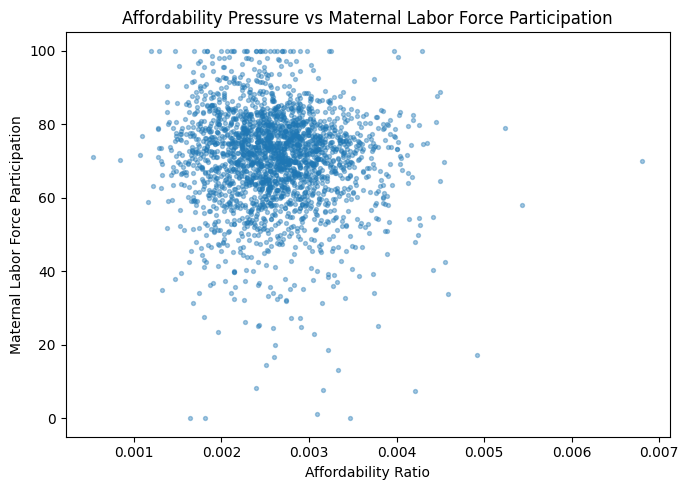

In [27]:
plt.figure(figsize=(7,5))
sub = df[["afford_ratio","flfpr_20to64_under6"]].dropna()
plt.scatter(sub["afford_ratio"], sub["flfpr_20to64_under6"], s=8, alpha=0.4)
plt.title("Affordability Pressure vs Maternal Labor Force Participation")
plt.xlabel("Affordability Ratio")
plt.ylabel("Maternal Labor Force Participation")
plt.tight_layout()
plt.show()


The relationship between childcare affordability pressure and maternal labor force participation is weak and highly dispersed. Counties with similar cost-to-income ratios often display very different participation outcomes, indicating that affordability alone does not fully explain maternal labor supply decisions

In [28]:
corr = df["afford_ratio"].corr(df["flfpr_20to64_under6"])
print("Correlation between affordability and maternal LFP:", round(corr, 3))


Correlation between affordability and maternal LFP: -0.08


The modest correlation between affordability pressure and maternal labor force participation reinforces the exploratory finding that childcare costs are only one of several factors influencing labor outcomes, motivating a structural rather than purely cost-based analysis.

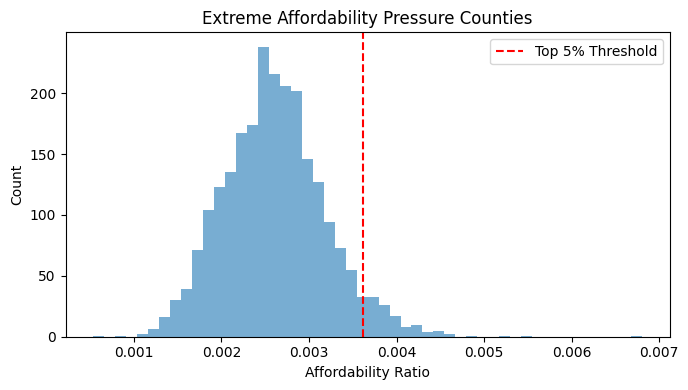

,county_name,state_abbreviation,afford_ratio,flfpr_20to64_under6
351,Greene County,AL,0.004466,87.8
472,Lowndes County,AL,0.003652,82.9
483,Macon County,AL,0.003779,82.1
549,Monroe County,AL,0.003818,83.8
582,Perry County,AL,0.004133,79.6
659,Sumter County,AL,0.004210,48.1
725,Wilcox County,AL,0.004134,66.7
802,Denali Borough,AK,0.003785,25.0
835,Haines Borough,AK,0.004012,98.3
988,Sitka City and Borough,AK,0.003890,80.2


In [29]:
q95 = df["afford_ratio"].quantile(0.95)
extreme = df[df["afford_ratio"] >= q95]

plt.figure(figsize=(7,4))
plt.hist(df["afford_ratio"].dropna(), bins=50, alpha=0.6)
plt.axvline(q95, color="red", linestyle="--", label="Top 5% Threshold")
plt.title("Extreme Affordability Pressure Counties")
plt.xlabel("Affordability Ratio")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

extreme[["county_name","state_abbreviation","afford_ratio","flfpr_20to64_under6"]].head(10)


Some states consistently exhibit higher median childcare affordability pressure, suggesting that regulatory and economic environments shape childcare markets at the state level. However, substantial within-state variation remains, indicating that state averages mask local heterogeneity.

In [30]:
aff_q75 = df["afford_ratio"].quantile(0.75)
aff_q25 = df["afford_ratio"].quantile(0.25)
lfp_q75 = df["flfpr_20to64_under6"].quantile(0.75)
lfp_q25 = df["flfpr_20to64_under6"].quantile(0.25)

high_cost_high_lfp = df[(df["afford_ratio"] >= aff_q75) & (df["flfpr_20to64_under6"] >= lfp_q75)]
moderate_cost_low_lfp = df[(df["afford_ratio"].between(aff_q25, aff_q75)) & (df["flfpr_20to64_under6"] <= lfp_q25)]

print("High cost + high participation:", len(high_cost_high_lfp))
print("Moderate cost + low participation:", len(moderate_cost_low_lfp))


High cost + high participation: 114
Moderate cost + low participation: 263


The presence of counties with high affordability pressure yet high maternal labor force participation, as well as counties with moderate costs but low participation, highlights meaningful mismatches between cost burden and labor outcomes. These patterns suggest that non-price structural factors play an important role in shaping maternal labor supply.